# Traveling Salesman Problem: Hill Climbing vs Simulated Annealing

**State:** a tour (order of cities) | **Neighbour:** 2-opt move (reverse a segment) | **Score:** total tour length (lower is better)

Run the cells top to bottom. Change the settings in the first code cell to try other sizes or your own cities.

In [64]:
import time, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rcParams
from IPython.display import HTML

%matplotlib inline
rcParams["animation.embed_limit"] = 60      # MB, needed for the animation cell
rcParams["figure.dpi"] = 100

# ===================== SETTINGS =====================
N_CITIES   = 200          # number of random cities
SEED       = 42           # change for a different map
ITERS      = 300_000      # iterations (move attempts) per algorithm
CITIES_CSV = None         # e.g. "cities.csv" with two columns x,y (no header). None = random cities
# ====================================================

## 1. Problem setup

In [65]:
rng = np.random.default_rng(SEED)

if CITIES_CSV:
    cities = np.loadtxt(CITIES_CSV, delimiter=",")[:, :2]
else:
    cities = rng.random((N_CITIES, 2)) * 100

n = len(cities)
assert n >= 5, "need at least 5 cities"

# pairwise distance matrix (n x n)
D = np.sqrt(((cities[:, None, :] - cities[None, :, :]) ** 2).sum(-1))

def tour_length(tour):
    return float(D[tour, np.roll(tour, -1)].sum())

def plot_tour(tour, ax, title=""):
    xy = cities[np.append(tour, tour[0])]
    ax.plot(xy[:, 0], xy[:, 1], "-", lw=1, color="tab:blue", zorder=1)
    ax.scatter(cities[:, 0], cities[:, 1], s=14, color="tab:red", zorder=2)
    ax.scatter(*cities[tour[0]], s=70, color="gold", edgecolor="k", zorder=3)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

def random_tour(rng):
    t = np.arange(n)
    t[1:] = rng.permutation(np.arange(1, n))     # city 0 stays first
    return t

def nearest_neighbor(start=0):
    left = set(range(n)); left.remove(start); tour = [start]
    while left:
        last = tour[-1]
        nxt = min(left, key=lambda c: D[last, c])
        tour.append(nxt); left.remove(nxt)
    return np.array(tour)

print(f"{n} cities | random tour length = {tour_length(random_tour(rng)):.1f}")

200 cities | random tour length = 10131.6


## 2. The algorithms

A **2-opt move** picks positions `i < j` and reverses the segment `tour[i..j]`. Only 2 edges change, so the length change is computed in O(1):

`delta = d(a,c) + d(b,d) - d(a,b) - d(c,d)`

- **Hill climbing:** accept only if `delta < 0`.
- **Random-restart hill climbing:** several hill-climbing runs from different random tours (same total budget), keep the best.
- **Simulated annealing:** also accept worse moves with probability `exp(-delta / T)` while `T` cools.

In [66]:
def _moves(rng, iters):
    """Pre-generate random 2-opt moves: 1 <= i < j <= n-1 (city at position 0 stays fixed)."""
    i = 1 + (rng.random(iters) * (n - 2)).astype(np.int64)
    j = i + 1 + (rng.random(iters) * (n - 1 - i)).astype(np.int64)
    return i.tolist(), j.tolist(), rng.random(iters).tolist()


def hill_climb(tour, iters, rng, log_every=1000):
    tour = tour.copy(); cur = tour_length(tour)
    I, J, _ = _moves(rng, iters)
    hist = []
    for k in range(iters):
        i, j = I[k], J[k]
        a, b, c, d = tour[i - 1], tour[i], tour[j], tour[(j + 1) % n]
        delta = D[a, c] + D[b, d] - D[a, b] - D[c, d]
        if delta < -1e-12:
            tour[i:j + 1] = tour[i:j + 1][::-1].copy()
            cur += delta
        if k % log_every == 0:
            hist.append(cur)
    return tour, cur, hist


def random_restart_hc(iters, rng, restarts=10, log_every=1000):
    best_tour, best_len, hist = None, np.inf, []
    for _ in range(restarts):
        t, L, h = hill_climb(random_tour(rng), iters // restarts, rng, log_every)
        hist += h
        if L < best_len:
            best_tour, best_len = t, L
    return best_tour, best_len, np.minimum.accumulate(hist).tolist()   # running best


def estimate_T0(tour, rng, samples=3000, p0=0.8):
    """Pick T0 so that ~p0 of worsening moves would be accepted at the start."""
    I, J, _ = _moves(rng, samples)
    worse = []
    for i, j in zip(I, J):
        a, b, c, d = tour[i - 1], tour[i], tour[j], tour[(j + 1) % n]
        delta = D[a, c] + D[b, d] - D[a, b] - D[c, d]
        if delta > 0:
            worse.append(delta)
    return float(np.mean(worse) / -math.log(p0))


NN_EDGE = tour_length(nearest_neighbor()) / n           # typical edge length, used to set T_end


def simulated_annealing(tour, iters, rng, schedule="geometric", T0=None, T_end=None,
                        log_every=1000, n_snaps=80):
    tour = tour.copy(); cur = tour_length(tour)
    T0 = T0 or estimate_T0(tour, rng)
    T_end = T_end or 0.01 * NN_EDGE
    temps = (np.geomspace(T0, T_end, iters) if schedule == "geometric"
             else np.linspace(T0, T_end, iters)).tolist()
    I, J, U = _moves(rng, iters)

    best, best_tour = cur, tour.copy()
    log = dict(it=[], cur=[], best=[], T=[], acc=[])
    snaps, snap_every = [], max(iters // n_snaps, 1)
    w_try = w_acc = 0

    for k in range(iters):
        i, j, T = I[k], J[k], temps[k]
        a, b, c, d = tour[i - 1], tour[i], tour[j], tour[(j + 1) % n]
        delta = D[a, c] + D[b, d] - D[a, b] - D[c, d]
        accept = False
        if delta < 0:
            accept = True
        else:
            w_try += 1
            if U[k] < math.exp(-delta / T):
                accept = True; w_acc += 1
        if accept:
            tour[i:j + 1] = tour[i:j + 1][::-1].copy()
            cur += delta
            if cur < best - 1e-12:
                best, best_tour = cur, tour.copy()
        if k % log_every == 0:
            log["it"].append(k); log["cur"].append(cur); log["best"].append(best)
            log["T"].append(T); log["acc"].append(w_acc / max(w_try, 1))
            w_try = w_acc = 0
        if k % snap_every == 0:
            snaps.append((k, tour.copy(), cur, T))
    return dict(tour=best_tour, length=best, log=log, snaps=snaps, T0=T0, T_end=T_end)

## 3. Run all methods from the same random start

In [67]:
start = random_tour(np.random.default_rng(SEED + 1))
results = {}

t0 = time.time(); nn = nearest_neighbor()
results["Nearest neighbour"] = dict(tour=nn, length=tour_length(nn), time=time.time() - t0, hist=None)

t0 = time.time(); t, L, h = hill_climb(start, ITERS, np.random.default_rng(1))
results["Hill climbing"] = dict(tour=t, length=L, time=time.time() - t0, hist=h)

t0 = time.time(); t, L, h = random_restart_hc(ITERS, np.random.default_rng(2))
results["Random-restart HC (10x)"] = dict(tour=t, length=L, time=time.time() - t0, hist=h)

t0 = time.time(); sa = simulated_annealing(start, ITERS, np.random.default_rng(3), "geometric")
results["Simulated annealing"] = dict(tour=sa["tour"], length=sa["length"], time=time.time() - t0, hist=sa["log"]["best"])

t0 = time.time(); sa_lin = simulated_annealing(start, ITERS, np.random.default_rng(3), "linear")
results["SA (linear cooling)"] = dict(tour=sa_lin["tour"], length=sa_lin["length"], time=time.time() - t0, hist=sa_lin["log"]["best"])

base = results["Nearest neighbour"]["length"]
print(f"{'Method':<26}{'Length':>10}{'vs NN':>10}{'Time (s)':>10}")
print("-" * 56)
for name, r in results.items():
    print(f"{name:<26}{r['length']:>10.1f}{(r['length'] / base - 1) * 100:>+9.1f}%{r['time']:>10.2f}")
print(f"\nSA start temperature T0 = {sa['T0']:.2f}, end temperature = {sa['T_end']:.3f}")

Method                        Length     vs NN  Time (s)
--------------------------------------------------------
Nearest neighbour             1291.7     +0.0%      0.00
Hill climbing                 1172.9     -9.2%      0.36
Random-restart HC (10x)       1291.9     +0.0%      0.35
Simulated annealing           1166.3     -9.7%      0.56
SA (linear cooling)           1792.0    +38.7%      0.64

SA start temperature T0 = 143.79, end temperature = 0.065


## 4. Final tours

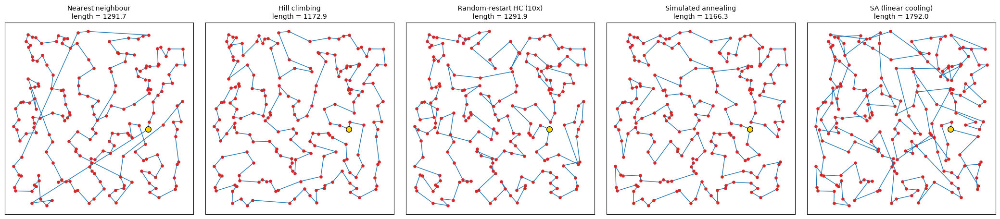

In [68]:
names = list(results)
fig, axes = plt.subplots(1, len(names), figsize=(4.2 * len(names), 4.4))
for ax, nm in zip(axes, names):
    plot_tour(results[nm]["tour"], ax, f"{nm}\nlength = {results[nm]['length']:.1f}")
plt.tight_layout(); plt.show()

## 5. Convergence (best length vs iteration)

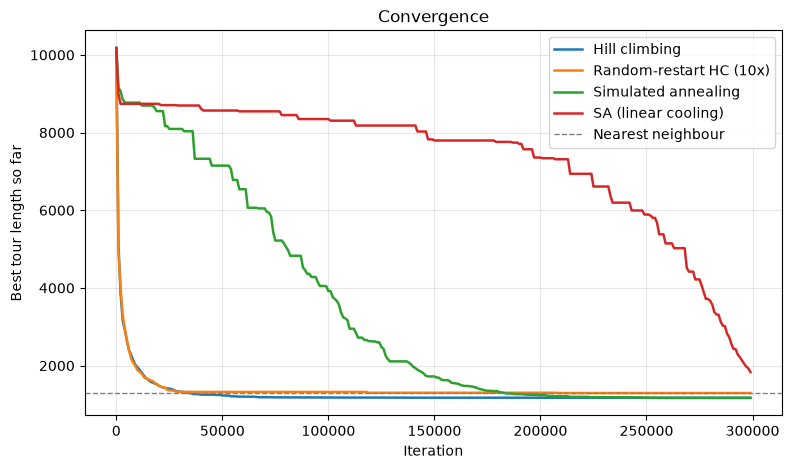

In [69]:
plt.figure(figsize=(9, 5))
for nm in names[1:]:
    h = results[nm]["hist"]
    plt.plot(np.arange(len(h)) * 1000, h, label=nm, lw=1.8)
plt.axhline(base, color="gray", ls="--", lw=1, label="Nearest neighbour")
plt.xlabel("Iteration"); plt.ylabel("Best tour length so far")
plt.title("Convergence"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Animated cooling

The route is the *current* tour at each snapshot, so you see it wander when `T` is high and settle as it cools. Press play on the widget.

In [70]:
def make_animation(res):
    frames = res["snaps"] + [(ITERS, res["tour"], res["length"], res["T_end"])] * 6
    fig, ax = plt.subplots(figsize=(6, 6))
    def update(f):
        ax.clear()
        k, t, L, T = frames[f]
        plot_tour(t, ax, f"iteration {k:,}   |   T = {T:.2f}   |   length = {L:.1f}")
    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=150)
    plt.close(fig)
    return HTML(anim.to_jshtml())

make_animation(sa)

## 7. Accepted worse moves vs temperature

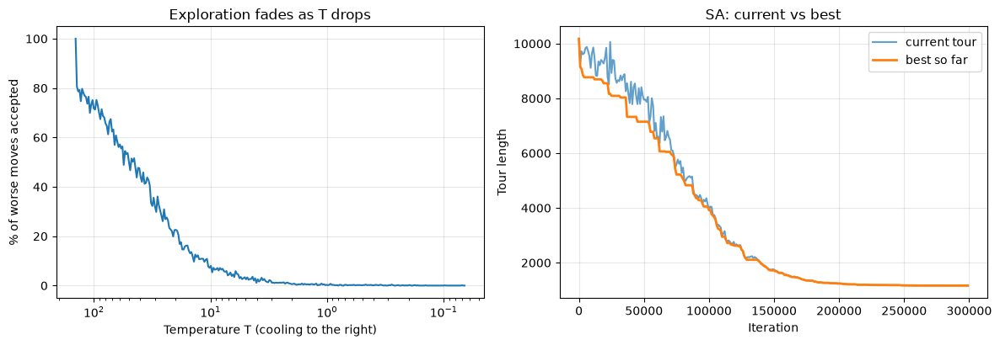

In [71]:
lg = sa["log"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].semilogx(lg["T"], np.array(lg["acc"]) * 100)
ax[0].invert_xaxis()
ax[0].set_xlabel("Temperature T (cooling to the right)")
ax[0].set_ylabel("% of worse moves accepted")
ax[0].set_title("Exploration fades as T drops"); ax[0].grid(alpha=0.3)

ax[1].plot(lg["it"], lg["cur"], label="current tour", alpha=0.7)
ax[1].plot(lg["it"], lg["best"], label="best so far", lw=2)
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Tour length")
ax[1].set_title("SA: current vs best"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Fair comparison over several random maps

Repeats the experiment on different random city sets and reports mean ± std. Reduce `RUNS` or `ITERS_STAT` if it is slow.

In [72]:
RUNS, ITERS_STAT = 5, 150_000
stats = {k: [] for k in ["Nearest neighbour", "Hill climbing", "Random-restart HC (10x)", "Simulated annealing"]}

_saved = (cities, D, n, NN_EDGE)
for r in range(RUNS):
    g = np.random.default_rng(1000 + r)
    cities = g.random((N_CITIES, 2)) * 100
    n = len(cities)
    D = np.sqrt(((cities[:, None, :] - cities[None, :, :]) ** 2).sum(-1))
    NN_EDGE = tour_length(nearest_neighbor()) / n
    s0 = random_tour(g)
    stats["Nearest neighbour"].append(tour_length(nearest_neighbor()))
    stats["Hill climbing"].append(hill_climb(s0, ITERS_STAT, g)[1])
    stats["Random-restart HC (10x)"].append(random_restart_hc(ITERS_STAT, g)[1])
    stats["Simulated annealing"].append(simulated_annealing(s0, ITERS_STAT, g)["length"])
cities, D, n, NN_EDGE = _saved                      # restore the main problem

print(f"{'Method':<26}{'mean':>9}{'std':>8}{'best':>9}")
print("-" * 52)
for k, v in stats.items():
    print(f"{k:<26}{np.mean(v):>9.1f}{np.std(v):>8.1f}{np.min(v):>9.1f}")

wins = sum(sa_ < min(hc, rr) for sa_, hc, rr in zip(stats["Simulated annealing"], stats["Hill climbing"], stats["Random-restart HC (10x)"]))
print(f"\nSA beat both hill-climbing variants on {wins}/{RUNS} maps")

Method                         mean     std     best
----------------------------------------------------
Nearest neighbour            1343.8    29.3   1309.1
Hill climbing                1208.6    32.5   1163.9
Random-restart HC (10x)      1624.4    35.3   1556.0
Simulated annealing          1174.3    13.3   1160.0

SA beat both hill-climbing variants on 4/5 maps


## Ideas to extend this

- Try `N_CITIES = 200` or `500` and watch the gap between hill climbing and SA change.
- Add an **Or-opt** move (move a short segment elsewhere) as a second neighbourhood.
- Add **reheating**: if there is no improvement for a long time, raise `T` a little.
- Compare with a reference solver such as OR-Tools (`pip install ortools`) to see how far from optimal SA is.
- Load real coordinates with `CITIES_CSV` (for example ground-station or city locations).